<a href="https://colab.research.google.com/github/Teapot-t/kurs-Uczenie-Maszynowe/blob/main/Zadanie3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler


In [ ]:
import kagglehub

#Pobieranie danych dotyczących credit card fraud z Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
#Wczytywanie danych
csv_file_name = '/creditcard.csv'

full_csv_path = path + csv_file_name
data = pd.read_csv(full_csv_path)
print(f"Successfully loaded data from {full_csv_path}")
data.head()


Successfully loaded data from /kaggle/input/creditcardfraud/creditcard.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#podział danych na treningowe testowe i walidację
X = data.drop('Class', axis=1) # Features
y = data['Class'] # Target variable

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2,stratify=y, random_state=48
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25,stratify=y_temp, random_state=48
)

In [ ]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model with increased max_iter
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
y_scores = model.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)
J = tpr - fpr
threshold = np.argmax(J)
best_threshold = thresholds[threshold]

print("Best threshold:", best_threshold)

Best threshold: 0.0023789855227503575


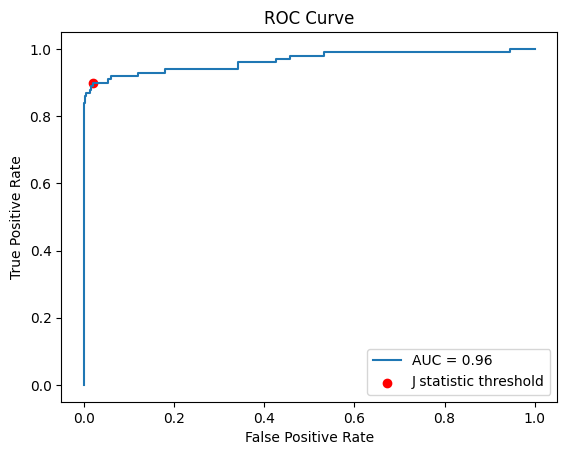

In [ ]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.scatter(fpr[threshold], tpr[threshold], color='red', label='J statistic threshold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

# Ewaluacja modelu regresji logistycznej z poziomem odcięcia ustalonym przy pomocy J statystyki Youndena
Maksymalizujemy sensitivity+specificity czyli szukamy punktu na krzywej ROC najdalej od przekątnej (odpowiadającej ROC klasyfikatora losowego)

In [ ]:
y_test_scores = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_test_scores >= best_threshold).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

Accuracy: 0.9799866577718479
Precision: 0.07084019769357495
Recall: 0.8775510204081632
Specificity: 0.9801631963984243
Sensitivity: 0.8775510204081632


# Dla porównania, ewaluujemy domyślny model regresji z punktem odcięcia 0.5

In [ ]:
y_test_scores_basic = model.predict_proba(X_test_scaled)[:, 1]
y_pred_basic = (y_test_scores_basic >= 0.5).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_basic))
print("Precision:", precision_score(y_test, y_pred_basic))
print("Recall:", recall_score(y_test, y_pred_basic))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_basic).ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("Specificity:", specificity)
print("Sensitivity:", sensitivity)

Accuracy: 0.9990519995786665
Precision: 0.8333333333333334
Recall: 0.5612244897959183
Specificity: 0.9998065559932471
Sensitivity: 0.5612244897959183


# Odpowiedzi na pytania

Pracujemy na zbiorze danych opisującym oszustwa związane z płatnościami dokonanymi przy pomocy kart kredytowych. Nasz zbiór danych jest przez to bardzo niezbalansowany - przytłaczająca większość płatności w obrocie jest "normalna", oszustwa stanowią niewielki odsetek zdarzeń, a zarazem mają duże i drogie konsekwencje.

1. Punkt odcięcia istotnie zmienia wynik klasyfikacji - jest podstawowym punktem odniesienia modelu. Jak widać, zmiana thresholdu istotnie zmienia wynik modelu. Obniżanie go zwiększa sensitivity, natomiast zmniejsza specificity modelu. Kluczowym elementem w wyborze odpowiedniego thresholdu jest zastosowanie i interpretacja modelu.
2. W naszym przypadku najważniejszym elementem jest rozpoznanie i zablokowanie fałszywych transakcji (recall). Dodatkowa weryfikacja płatności w formie telefonu do klienta czy innych dodatkowych metod stosowanych przez banki nie jest ani trochę tak problematyczna i kosztowna jak odzyskiwanie czy zwracanie pieniędzy, które zostały wydane w wyniku oszustwa. Co więcej kosztem licznych false negatives jest też koszt wizerunkowy całego systemu, jako że opiera się w większości na powszechnym zaufaniu społecznym. Dlatego musimy priorytetyzować model dający jak najlepszy recall.
Podobnie byłoby w przypadku wykrywania chorób - osoba, której nie udzielono pomocy ponosi duży uszczerbek na zdrowiu. Przeciwnie natomiast w systemach pokroju systemów wykrywających spam. Okazjonalne usunięcie niepożądanej reklamy ze skrzynki pocztowej jest proste, natomiast nie otrzymanie ważnej informacji może być kosztowne. Wtedy chcemy aby model filtrował większość spamu ale nie blokował żadnych normalnych wiadomości.
3. Krzywa ROC pozwala nam na ocenienie naszego modelu niezależnie od wybranego thresholdu, widzimy jego osiągi dla każdego punktu odcięcia. Pozwala nam to na wybór zbalansowanego punktu odcięcia.
4. Na potrzeby zadania skorzystałem z J statystyki Youdena - punktu na krzywej ROC najdalej od przekątnej (odpowiadającej ROC klasyfikatora losowego). Odpowiada to zbalansowanemu podejściu do problemu - nie chcemy przepuszczać fałszywych transakcji ani irytować klientów ciągłymi kontrolami i blokowaniem kart. W sekcji ewaluacji widać, że tak wyznaczony threshold istotnie poprawia wykrywalność oszustw względem domyślnego parametru 0.5 - recall wzrósł z 0.56 do 0.88. W praktyce lepszym biznesowo sposobem byłaby metoda oparta o wycenę błędu, przez uwzględnienie kosztu dodatkowej kontroli jak i wycenę niewykrycia oszustwa uwzględniając koszt wizerunkowy, po czym optymalizowanie tak dopasowanej do problemu statystyki.
5. AUC (Area under a Curve) jako metryka wykorzystuje pole pod krzywą ROC i pokazuje jak dobrze zadanie klasyfikacji spełnia wybrany przez nas klasyfikator nauczony na naszych danych. Pozwala na ocenę, czy nasz klasyfikator w ogóle nadaje się do badania danego zagadnienia lub czy mamy dostatecznie dużo danych. Odpowiada na pytanie, czy nasz model jest w stanie dobrze oddzielić klasy.